In [1]:
import yfinance as yf
import pandas as pd

wti = yf.download('CL=F', period="5y")
brent = yf.download('BZ=F', period="5y")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
wti.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


In [3]:
wti.tail()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2026-05-19,107.769997,109.239998,106.760002,107.110001,206472
2026-05-20,98.260002,104.449997,96.940002,104.120003,320034
2026-05-21,96.349998,102.660004,95.760002,98.949997,345482
2026-05-22,96.599998,99.430000,94.730003,98.000000,261142
2026-05-26,92.989998,93.690002,92.809998,93.389999,5177


Question i encountered at first sight

why the opening price of next day's trade is diffrent from closing price of previous day's trade?

In [4]:
wti[['Open','Close']].head(10)

Price,Open,Close
Ticker,CL=F,CL=F
Date,,
2021-05-26,66.040001,66.209999
2021-05-27,66.160004,66.849998
2021-05-28,66.949997,66.320000
2021-06-01,66.680000,67.720001
2021-06-02,67.989998,68.830002
2021-06-03,68.760002,68.809998
2021-06-04,68.910004,69.620003
2021-06-07,69.519997,69.230003


Answer to the above question is- 
The price difference between the previous day’s closing price and the current day’s opening price is called an 'overnight gap', caused by new market information and trading sentiment outside the regular session/offical time.

Globally important assets like crude oil, currencies, gold, and cryptocurrencies trade nearly 24/7 because worldwide demand, economic activity, and market participation continue across different time zones.
And oil is highly demand assest to the world.

In [5]:
wti.describe()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,77.880255,79.349141,76.410907,77.932371,3.207558e+05
std,13.085143,13.711566,12.462701,13.118484,1.272022e+05
min,55.270000,56.700001,54.980000,55.230000,0.000000e+00
25%,69.160004,70.180000,67.949997,69.230003,2.595400e+05
50%,75.660004,77.089996,74.269997,75.739998,3.179390e+05
75%,83.570000,84.919998,82.150002,83.580002,3.784730e+05
max,123.699997,130.500000,120.790001,124.660004,1.107193e+06


Then what is the use of close and open in these assests?

Because stock exchanges historically needed standarized session:
1. centralized matching
2. settlement
3. regulation
4. fairness
5. liquidity concentration

Imagine this chaos:
One analyst starts day at 12 AM
Another at 4 AM
Another at London open
Another at New York open.

In [6]:
wti.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1257 entries, 2021-05-26 to 2026-05-26
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, CL=F)   1257 non-null   float64
 1   (High, CL=F)    1257 non-null   float64
 2   (Low, CL=F)     1257 non-null   float64
 3   (Open, CL=F)    1257 non-null   float64
 4   (Volume, CL=F)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


Data Modeling

Why Flattening is important?
Flattening makes:
1. code cleaner
2. analysis easier
3. plotting easier
4. ML preprocessing easier
5. debugging easier

When you should NOT flatten? 
Keep MultiIndex when hierarchy matters. Now MultiIndex becomes powerful for:
1. portfolio analysis
2. sector comparison
3. multi-asset correlation
4. grouped operations

In [7]:
wti.columns = wti.columns.get_level_values(0)
wti.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


In [8]:
# price is a column name 
wti.columns.name = None
wti.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


Index - index used as basline to compare

In [9]:
wti.reset_index(inplace=True)
wti.head()

,Date,Close,High,Low,Open,Volume
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


In [10]:
wti.set_index('Date', inplace=True)
wti.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


In [11]:
# again flatten column
wti.reset_index(inplace=True)
wti.columns.name = None
wti.head()

,Date,Close,High,Low,Open,Volume
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


In [12]:
# standarize all column to lower
wti.columns = wti.columns.str.lower()
wti.head()

,date,close,high,low,open,volume
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995


Problem Statement - Analysis of oil prices

My First Real Feature Engineering

In [13]:
wti[["open", "close"]].head(10)

,open,close
0,66.040001,66.209999
1,66.160004,66.849998
2,66.949997,66.320000
3,66.680000,67.720001
4,67.989998,68.830002
5,68.760002,68.809998
6,68.910004,69.620003
7,69.519997,69.230003
8,69.290001,70.050003
9,70.010002,69.959999


Finding the gap

In [14]:
# previous close as a new column - so that when we pull entire single row it will give prev_close 
wti['prev_close'] = wti['close'].shift(1)
wti.head()

,date,close,high,low,open,volume,prev_close
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207,NaN
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,66.209999
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001


In [15]:
# daily gap
wti['gap'] = wti['open'] - wti['prev_close']
wti['gap'].head(5)

0         NaN
1   -0.049995
2    0.099998
3    0.360001
4    0.269997
Name: gap, dtype: float64

In [16]:
# 2days_gap
wti['2daysago_close'] = wti['close'].shift(2)
wti['2days_gap'] = wti['open'] - wti['2daysago_close']
wti.head()

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207,NaN,NaN,NaN,NaN
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,66.209999,-0.049995,NaN,NaN
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,66.209999,0.739998
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998


In [17]:
#bigger value in gap
wti[['gap', '2days_gap']].max()

gap           7.980003
2days_gap    16.989998
dtype: float64

In [18]:
# bigger value in gap row
# Which day had the biggest overnight opening_gap/shock?
wti.loc[wti['gap'].idxmax()].to_frame().T  
# to_frame.T used to make a one liner 

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
1197,2026-03-02 00:00:00,71.230003,75.330002,69.199997,75.0,881329,67.019997,7.980003,65.209999,9.790001


Large gaps often indicate overnight uncertainty or volatility caused by major events/news.
1. Russia-Ukraine war
2. OPEC production cuts
3. Weekend geopolitical news

In [19]:
wti.loc[[wti['gap'].idxmax(), wti['2days_gap'].idxmax()]]

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
1197,2026-03-02,71.230003,75.330002,69.199997,75.0,881329,67.019997,7.980003,65.209999,9.790001
1202,2026-03-09,94.769997,119.480003,81.190002,98.0,1107193,90.900002,7.099998,81.010002,16.989998


In [20]:
# Which day had biggest crash?
wti.loc[wti['gap'].idxmin()].to_frame().T

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
1203,2026-03-10 00:00:00,83.449997,91.480003,76.730003,85.75,801564,94.769997,-9.019997,90.900002,-5.150002


In [21]:
# Intraday_move/Volatility
wti['intraday_move'] = wti['high'] - wti['low']
wti.head()

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207,NaN,NaN,NaN,NaN,1.180000
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,66.209999,-0.049995,NaN,NaN,1.449997
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,66.209999,0.739998,1.349998
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998,2.459999
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998,1.220001


In [22]:
# Days where volatility was extreme
# Which days had massive intraday movement?
wti.loc[wti['intraday_move'].idxmax()].to_frame().T

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
1202,2026-03-09 00:00:00,94.769997,119.480003,81.190002,98.0,1107193,90.900002,7.099998,81.010002,16.989998,38.290001


In [23]:
# Which days had massive intraday movement greater than 10?
wti.loc[wti['high'] - wti['low'] > 10]

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
128,2021-11-26,68.150002,78.650002,67.400002,78.339996,844630,78.389999,-0.050003,78.500000,-0.160004,11.250000
192,2022-03-01,103.410004,106.779999,95.320000,96.089996,698814,95.720001,0.369995,91.589996,4.500000,11.459999
194,2022-03-03,107.669998,116.570000,106.430000,111.330002,592031,110.599998,0.730003,103.410004,7.919998,10.139999
196,2022-03-07,119.400002,130.500000,115.540001,121.330002,576022,115.680000,5.650002,107.669998,13.660004,14.959999
197,2022-03-08,123.699997,129.440002,117.070000,120.669998,583106,119.400002,1.269997,115.680000,4.989998,12.370003
198,2022-03-09,108.699997,126.839996,103.629997,124.660004,594773,123.699997,0.960007,119.400002,5.260002,23.209999
211,2022-03-28,105.959999,112.930000,102.830002,112.919998,372251,113.900002,-0.980003,112.339996,0.580002,10.099998
268,2022-06-17,109.559998,118.970001,108.250000,117.080002,103149,117.589996,-0.509995,115.309998,1.770004,10.720001
278,2022-07-05,99.500000,111.449997,97.430000,108.800003,594215,108.430000,0.370003,105.760002,3.040001,14.019997
1023,2025-06-23,68.510002,78.400002,66.599998,78.000000,728868,74.930000,3.070000,75.139999,2.860001,11.800003


In [24]:
# Top 10 most volatile oil trading days in history
wti.loc[wti['intraday_move'].sort_values(ascending=False).head(10).index, ['open', 'high', 'low', 'close', 'intraday_move']]

,open,high,low,close,intraday_move
1202,98.000000,119.480003,81.190002,94.769997,38.290001
198,124.660004,126.839996,103.629997,108.699997,23.209999
1223,108.739998,109.190002,91.050003,94.410004,18.139999
1212,100.510002,101.669998,84.370003,88.129997,17.299995
1220,98.919998,113.970001,97.500000,111.540001,16.470001
196,121.330002,130.500000,115.540001,119.400002,14.959999
1203,85.750000,91.480003,76.730003,83.449997,14.750000
1201,79.080002,92.610001,78.239998,90.900002,14.370003
1243,102.699997,102.699997,88.660004,95.080002,14.039993
278,108.800003,111.449997,97.430000,99.500000,14.019997


another professional way
1. wti.nlargest(10, 'intraday_move')

# Exploratory Data Analysis

In [46]:
wti.info()

<class 'pandas.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   date                1257 non-null   datetime64[s]
 1   close               1257 non-null   float64      
 2   high                1257 non-null   float64      
 3   low                 1257 non-null   float64      
 4   open                1257 non-null   float64      
 5   volume              1257 non-null   int64        
 6   prev_close          1256 non-null   float64      
 7   gap                 1256 non-null   float64      
 8   2daysago_close      1255 non-null   float64      
 9   2days_gap           1255 non-null   float64      
 10  intraday_move       1257 non-null   float64      
 11  rolling_volatility  1238 non-null   float64      
dtypes: datetime64[s](1), float64(10), int64(1)
memory usage: 118.0 KB


In [47]:
wti.index

RangeIndex(start=0, stop=1257, step=1)

In [48]:
wti.head()

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move,rolling_volatility
0,2021-05-26,66.209999,66.430000,65.250000,66.040001,376207,NaN,NaN,NaN,NaN,1.180000,NaN
1,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,66.209999,-0.049995,NaN,NaN,1.449997,NaN
2,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,66.209999,0.739998,1.349998,NaN
3,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998,2.459999,NaN
4,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998,1.220001,NaN


In [49]:
wti.set_index("date", inplace=True)

In [50]:
wti.head()

,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move,rolling_volatility
date,,,,,,,,,,,
2021-05-26,66.209999,66.430000,65.250000,66.040001,376207,NaN,NaN,NaN,NaN,1.180000,NaN
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,66.209999,-0.049995,NaN,NaN,1.449997,NaN
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,66.209999,0.739998,1.349998,NaN
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998,2.459999,NaN
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998,1.220001,NaN


In [58]:
wti.index

DatetimeIndex(['2021-05-26', '2021-05-27', '2021-05-28', '2021-06-01',
               '2021-06-02', '2021-06-03', '2021-06-04', '2021-06-07',
               '2021-06-08', '2021-06-09',
               ...
               '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15',
               '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21',
               '2026-05-22', '2026-05-26'],
              dtype='datetime64[s]', name='date', length=1257, freq=None)

Why financial analysts almost always use datetime index? 

Because financial data is time-dependent, and datetime index makes time-based analysis fast and natural.

In [56]:
wti.loc['2024']

,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move,rolling_volatility
date,,,,,,,,,,,
2024-01-02,70.379997,73.639999,70.059998,71.709999,330992,71.650002,0.059998,71.769997,-0.059998,3.580002,2.393501
2024-01-03,72.699997,73.230003,69.279999,70.500000,334861,70.379997,0.120003,71.650002,-1.150002,3.950005,2.471001
2024-01-04,72.190002,74.000000,71.059998,73.040001,344467,72.699997,0.340004,70.379997,2.660004,2.940002,2.513001
2024-01-05,73.809998,74.239998,72.209999,72.400002,325525,72.190002,0.209999,72.699997,-0.299995,2.029999,2.440001
2024-01-08,70.769997,73.949997,70.129997,73.510002,392249,73.809998,-0.299995,72.190002,1.320000,3.820000,2.547001
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,70.099998,70.430000,69.360001,69.559998,122602,69.239998,0.320000,69.459999,0.099998,1.070000,1.583000
2024-12-26,69.620003,70.750000,69.330002,70.199997,144877,70.099998,0.099998,69.239998,0.959999,1.419998,1.541500
2024-12-27,70.599998,70.750000,69.440002,69.680000,172641,69.620003,0.059998,70.099998,-0.419998,1.309998,1.547499


In [59]:
wti.loc['2024-01']

,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move,rolling_volatility
date,,,,,,,,,,,
2024-01-02,70.379997,73.639999,70.059998,71.709999,330992,71.650002,0.059998,71.769997,-0.059998,3.580002,2.393501
2024-01-03,72.699997,73.230003,69.279999,70.500000,334861,70.379997,0.120003,71.650002,-1.150002,3.950005,2.471001
2024-01-04,72.190002,74.000000,71.059998,73.040001,344467,72.699997,0.340004,70.379997,2.660004,2.940002,2.513001
2024-01-05,73.809998,74.239998,72.209999,72.400002,325525,72.190002,0.209999,72.699997,-0.299995,2.029999,2.440001
2024-01-08,70.769997,73.949997,70.129997,73.510002,392249,73.809998,-0.299995,72.190002,1.320000,3.820000,2.547001
2024-01-09,72.239998,72.930000,70.470001,70.910004,363445,70.769997,0.140007,73.809998,-2.899994,2.459999,2.563501
2024-01-10,71.370003,73.589996,71.010002,72.169998,352772,72.239998,-0.070000,70.769997,1.400002,2.579994,2.619501
2024-01-11,72.019997,73.809998,71.169998,71.330002,373645,71.370003,-0.040001,72.239998,-0.909996,2.639999,2.564501
2024-01-12,72.680000,75.250000,72.360001,73.010002,403636,72.019997,0.990005,71.370003,1.639999,2.889999,2.600001


Moving Average/Rolling window

In [71]:
#1 Closing price trend
wti['MA7'] = wti['close'].rolling(7).mean()

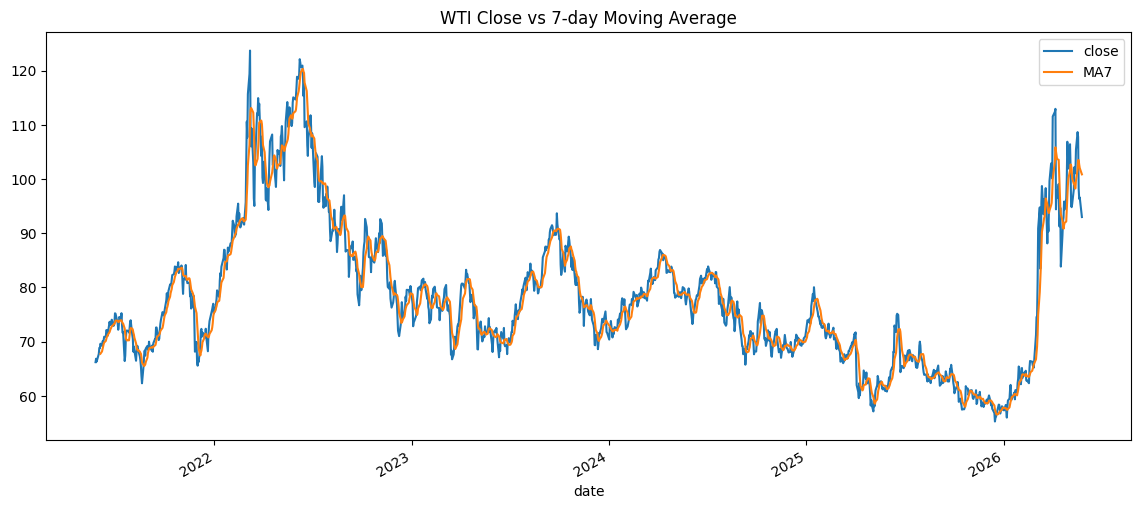

In [70]:
import matplotlib.pyplot as plt

wti[["close", "MA7"]].plot(figsize=(14,6))
plt.title("WTI Close vs 7-day Moving Average")
plt.show()

Copied plotly - from internet to just see how it work

In [67]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


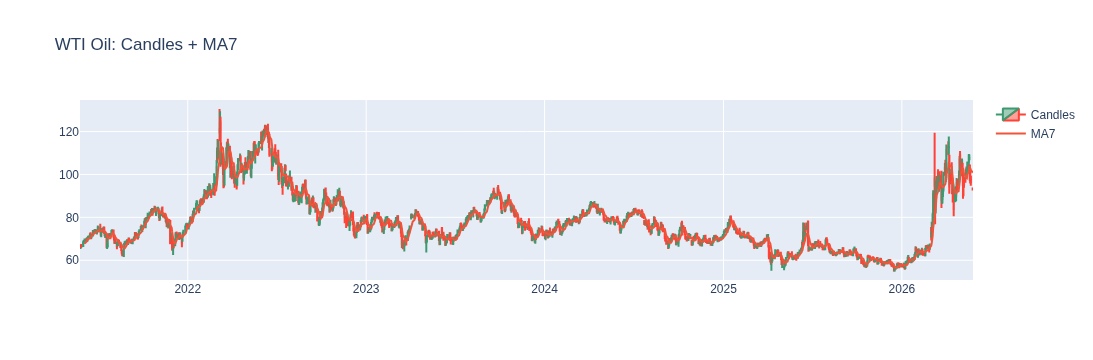

In [69]:
import plotly.graph_objects as go

fig = go.Figure()

# Candles
fig.add_trace(go.Candlestick(
    x=wti.index,
    open=wti["open"],
    high=wti["high"],
    low=wti["low"],
    close=wti["close"],
    name="Candles"
))

# Moving average
wti["MA7"] = wti["close"].rolling(7).mean()

fig.add_trace(go.Scatter(
    x=wti.index,
    y=wti["MA7"],
    mode="lines",
    name="MA7"
))

fig.update_layout(
    title="WTI Oil: Candles + MA7",
    xaxis_rangeslider_visible=False
)

fig.show()

In [72]:
#2 30-day moving average
wti['MA30'] = wti['close'].rolling(30).mean()

Text(0.5, 1.0, 'WTI close vs 30-day Moving Average')

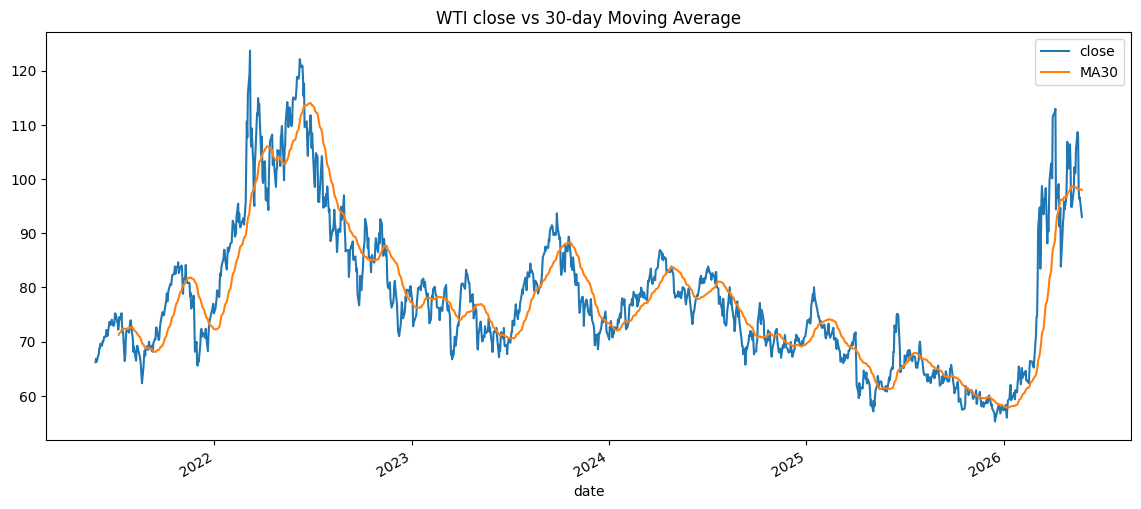

In [76]:
wti[['close', 'MA30']].plot(figsize= (14,6))
plt.title("WTI close vs 30-day Moving Average")

Text(0.5, 1.0, 'WTI close vs 200-day Moving Average')

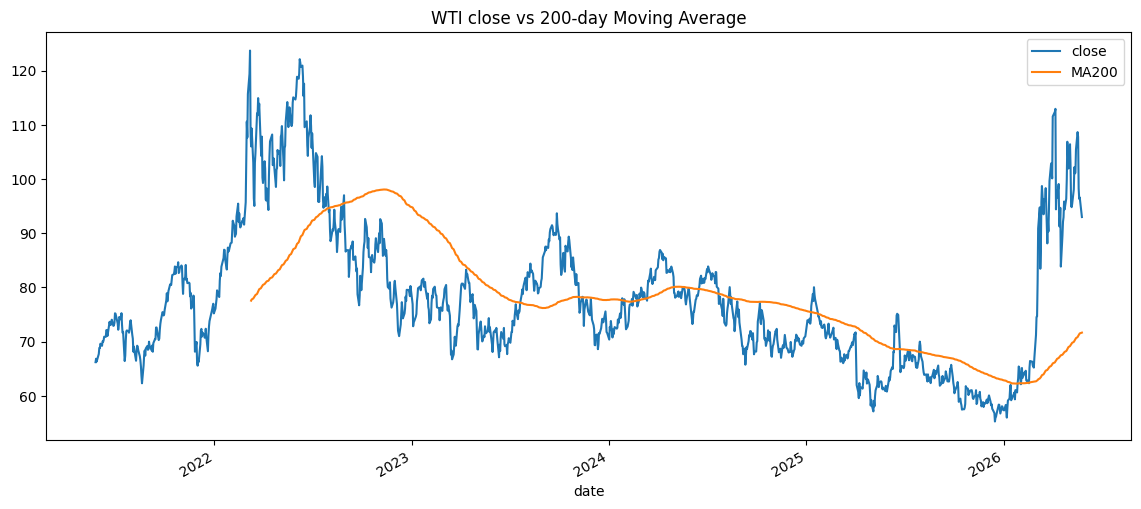

In [77]:
#2 30-day moving average
wti['MA200'] = wti['close'].rolling(200).mean()
wti[['close', 'MA200']].plot(figsize= (14,6))
plt.title("WTI close vs 200-day Moving Average")

<Axes: xlabel='date'>

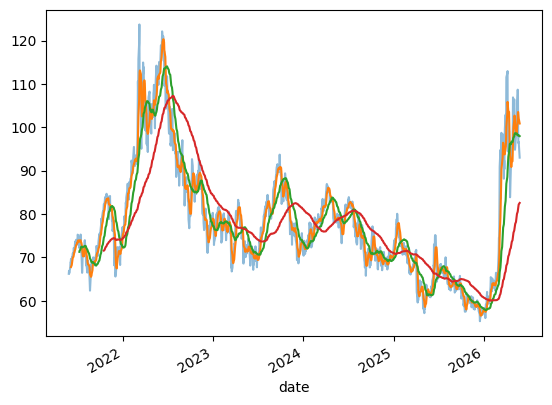

In [79]:
wti["close"].plot(alpha=0.5)
wti["close"].rolling(7).mean().plot()
wti["close"].rolling(30).mean().plot()
wti["close"].rolling(100).mean().plot()